In [1]:
# Standard Python modules 
import os, sys 
import glob 
import numpy as np 
import pandas as pd 
import xarray as xr 
import re 
from datetime import datetime, timedelta 

path_to_data = '/cw3e/mead/projects/cwp162/data/' 
path_to_out = '../out/' # output files (numerical results, intermediate datafiles) -- read & write 
path_to_figs = '../figs/' # figures 

## Load tARgetv4 AR data 
fname = path_to_data + 'downloads/globalARcatalog_ERA5_1940-2024_v4.0.nc' 
ds = xr.open_dataset(fname) 
ds = ds.isel(lev=0, ens=0).squeeze() 
## load in ARID list for HUC8 
ARID = 200812241803
# Convert to string for safe slicing 
ARID_str = str(ARID).zfill(12) 
# Parse date portion (YYYYMMDDHH) 
dt = datetime.strptime(ARID_str[:10], "%Y%m%d%H") 
# Extract last two digits as ID 
ID = int(ARID_str[-2:]) 
# Optional: formatted date string 
date_str = dt.strftime("%Y-%m-%d %H:%M") 
print(dt) # datetime object 
print(date_str) 
# formatted string 
print(ID) # integer 0–99 
tmp = ds.sel(time=date_str) 
## landfall lat and lon - one lat/lon per ARID 
lflat = tmp.lflat.isel(lat=ID-1).values 
lflon = tmp.lflon.isel(lat=ID-1).values 
lfivtx = tmp.lfivtx.isel(lat=ID-1).values 
lfivty = tmp.lfivty.isel(lat=ID-1).values 
lfivtdir = tmp.lfivtdir.isel(lat=ID-1).values 
print(lflat, lflon, lfivtx, lfivty, lfivtdir) 
## get date 14 days after AR starts 
## probably the lifetime of the AR does not extend past this 
dt2 = dt + timedelta(hours=14*24) 
date_str2 = dt2.strftime("%Y-%m-%d %H:%M") 
## slice to start date and 14 days after start date 
tmp2 = ds.sel(time=slice(date_str, date_str2)) 

# find maximum date of ARID 
date_ds = tmp2.kidmap.where(tmp2.kidmap == ARID, drop=True) 
max_date = date_ds.time.values[-1] 
print(max_date) 
## pull the "trajectory" of the AR during it's lifetime 
date_lst = date_ds.time.values 
clat_lst = [] 
clon_lst = [] 
for date in date_lst: 
    tmp3 = ds.sel(time=date) 
    ## find new ID from ds.shapemap 
    ## the ID changes every time step 
    new_ID = int(tmp3.shapemap.where(tmp3.kidmap==ARID).max().values) 
    ## for each time step the ARID is present, what is the head lat and head lon? 
    clat = tmp3.clat.isel(lat=new_ID-1).values 
    clon = tmp3.clon.isel(lat=new_ID-1).values 
    clat_lst.append(clat) 
    clon_lst.append(clon) 

# old trusted code output
print(clat_lst[:5], clon_lst[:5])

2008-12-24 18:00:00
2008-12-24 18:00
3
34.75 239.25 -7.9648438 324.66943 358.5947
2008-12-30T00:00:00.000000000
[array(31.124144, dtype=float32), array(31.74779, dtype=float32), array(32.60324, dtype=float32), array(33.05477, dtype=float32), array(35.03422, dtype=float32)] [array(239.27426, dtype=float32), array(241.21419, dtype=float32), array(244.82957, dtype=float32), array(247.45903, dtype=float32), array(252.48828, dtype=float32)]


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import sys, os

import geopandas as gpd
from shapely.geometry import Point, LineString

import cartopy
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec

# cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('modules')
from plotter import draw_basemap, plot_terrain
import customcmaps as ccmap

path_to_data = '/cw3e/mead/projects/cwp162/data/'
path_to_out  = '../out/'       # output files (numerical results, intermediate datafiles) -- read & write
path_to_figs = 'figs/'      # figures

traj_df = pd.read_parquet("out/traj_all.parquet")
traj_df = traj_df.dropna(subset=["clat", "clon", "time"])

# Convert 0–360 → −180–180
traj_df["clon"] = ((traj_df["clon"] + 180) % 360) - 180

gdf_points = gpd.GeoDataFrame(
    traj_df,
    geometry=gpd.points_from_xy(traj_df.clon, traj_df.clat),
    crs="EPSG:4326"
)

lines = []
points = []

for arid, g in traj_df.groupby("ARID"):
    g = g.sort_values("time").dropna(subset=["clat", "clon"])

    coords = list(zip(g.clon.values, g.clat.values))

    if len(coords) == 1:
        points.append({
            "ARID": arid,
            "geometry": Point(coords[0])
        })
    elif len(coords) > 1:
        lines.append({
            "ARID": arid,
            "geometry": LineString(coords)
        })

gdf_lines  = gpd.GeoDataFrame(lines,  crs="EPSG:4326")
gdf_points = gpd.GeoDataFrame(points, crs="EPSG:4326")



In [3]:
from shapely.geometry import LineString, MultiLineString
import numpy as np

def split_linestring_at_dateline(line, threshold=180):
    if line is None or line.is_empty:
        return line

    coords = np.asarray(line.coords)

    # Must have at least 2 points to be a LineString
    if coords.shape[0] < 2:
        return line

    lons = coords[:, 0]
    jumps = np.where(np.abs(np.diff(lons)) > threshold)[0]

    if len(jumps) == 0:
        return line

    segments = []
    start = 0

    for j in jumps:
        seg = coords[start:j+1]
        if len(seg) >= 2:                # guard
            segments.append(LineString(seg))
        start = j + 1

    # final segment
    seg = coords[start:]
    if len(seg) >= 2:                    # guard
        segments.append(LineString(seg))

    if len(segments) == 1:
        return segments[0]

    return MultiLineString(segments)


In [4]:
gdf_lines["geometry"] = gdf_lines.geometry.apply(split_linestring_at_dateline)


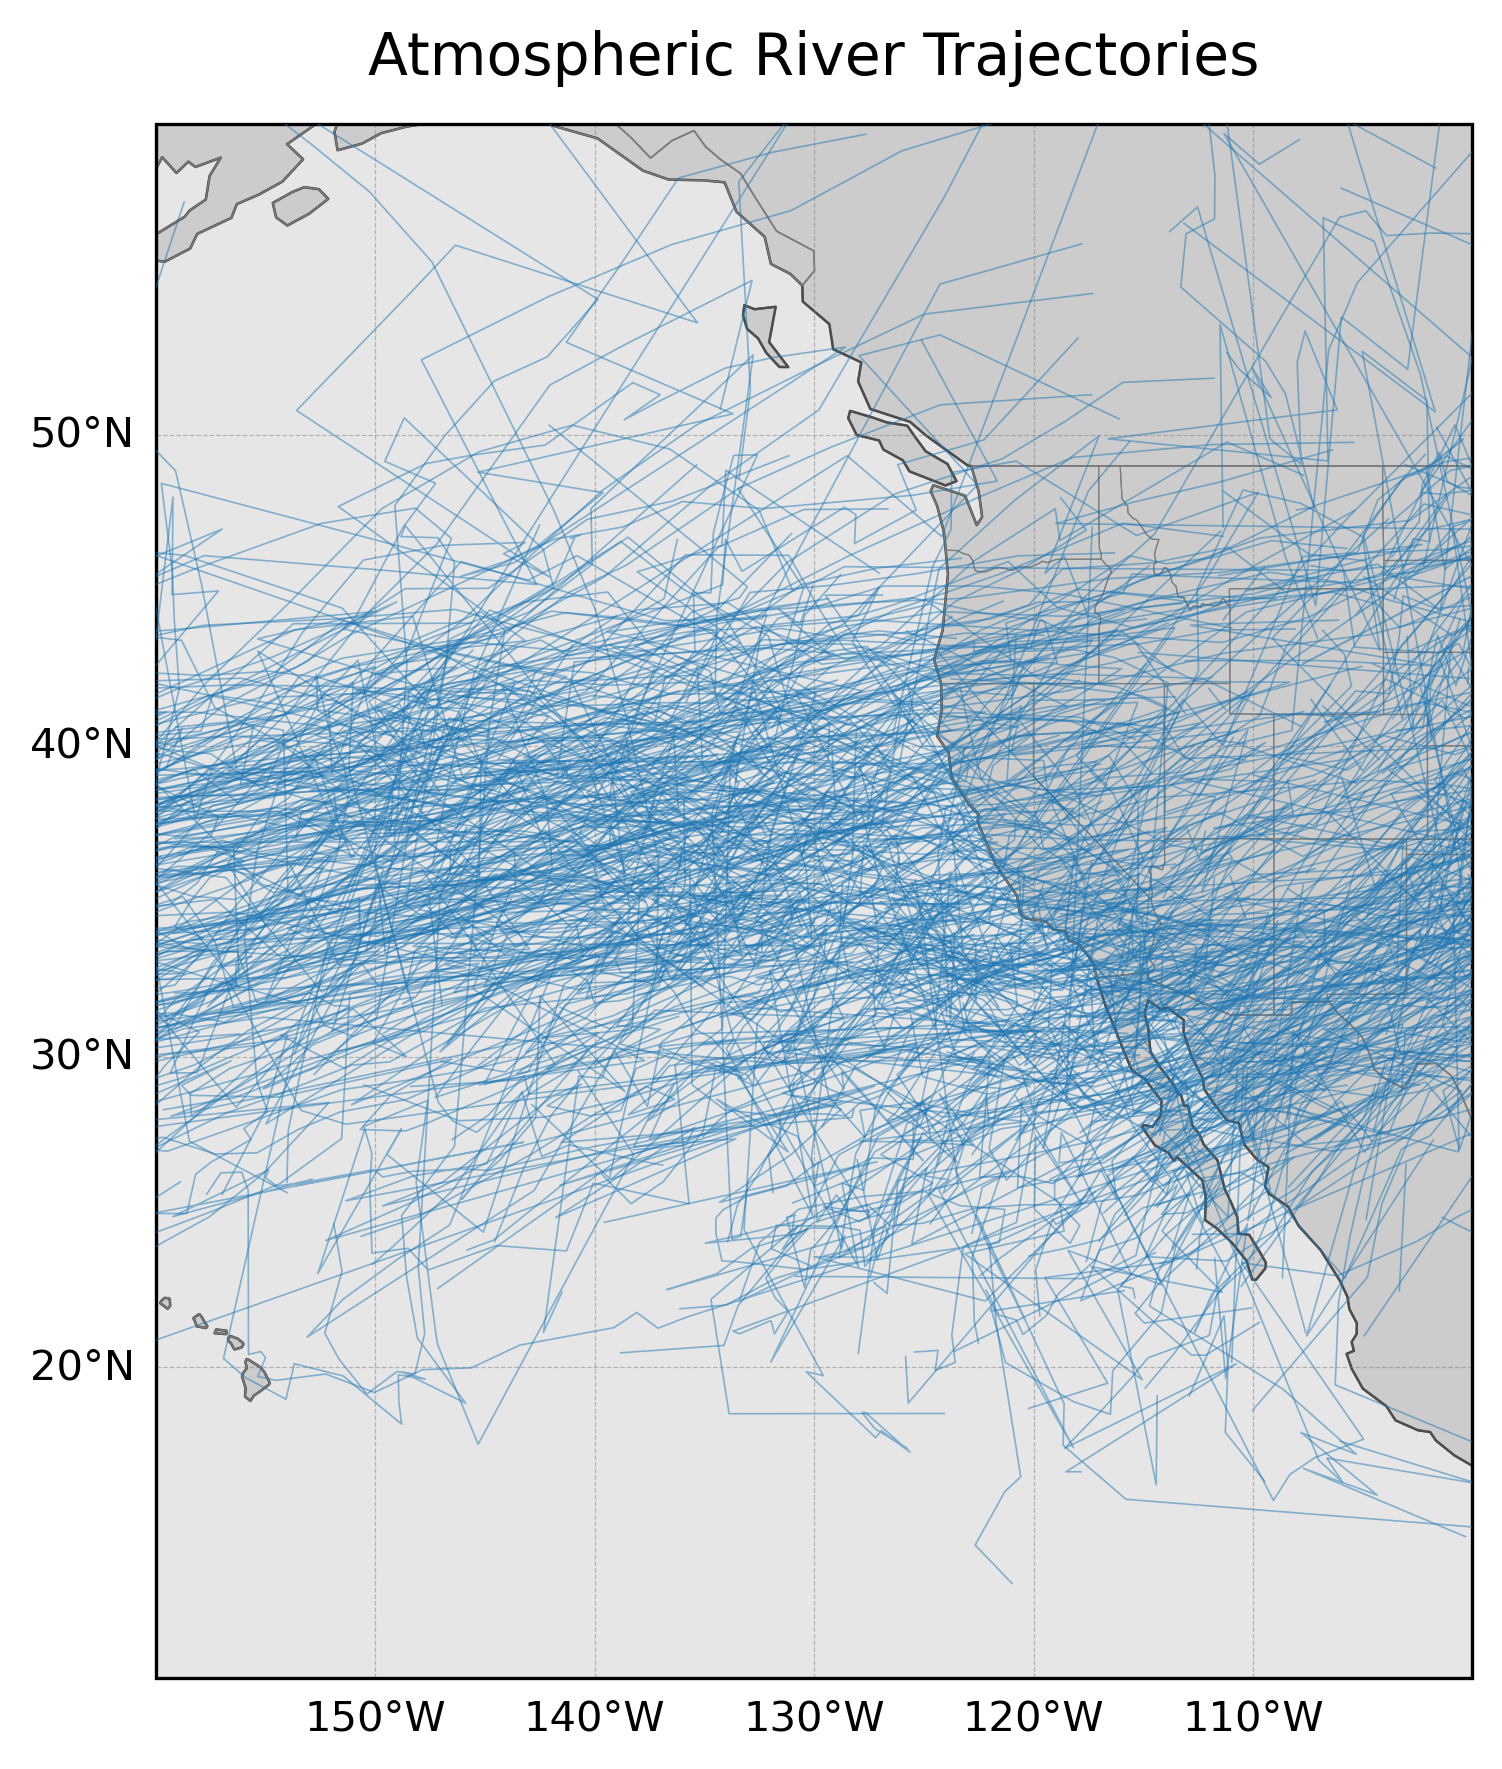

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---- Projections ----
datacrs = ccrs.PlateCarree()
mapcrs  = ccrs.PlateCarree(central_longitude=180)

# ---- Figure ----
fig = plt.figure(figsize=(10, 6), dpi=300)
ax = plt.axes(projection=mapcrs)

# ---- Map extent (Pacific-centered) ----
# This corresponds roughly to: 120E → 110W
ax.set_extent([200, 260, 10, 60], crs=datacrs)

# ---- Grey basemap ----
ax.add_feature(
    cfeature.OCEAN,
    facecolor="0.9",
    zorder=0
)
ax.add_feature(
    cfeature.LAND,
    facecolor="0.8",
    edgecolor="0.4",
    linewidth=0.5,
    zorder=1
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.6,
    edgecolor="0.3",
    zorder=2
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.4,
    edgecolor="0.4",
    zorder=2
)

ax.add_feature(
    cfeature.STATES,
    linewidth=0.3,
    edgecolor="0.5",
    zorder=2
)

# ---- Gridlines (subtle) ----
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="0.5",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# ---- Plot trajectories ----
gdf_lines.plot(
    ax=ax,
    transform=datacrs,      # 🔑 tells Cartopy how to interpret geometry
    linewidth=0.4,
    alpha=0.5,
    color="tab:blue",
    zorder=10
)

# ---- Title ----
ax.set_title(
    "Atmospheric River Trajectories",
    fontsize=14,
    pad=12
)

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import pandas as pd

traj_df = pd.read_parquet("out/traj_all.parquet")

# Clean
traj_df = traj_df.dropna(subset=["clat", "clon"])

# Convert 0–360 → −180–180 if needed
traj_df["clon"] = ((traj_df["clon"] + 180) % 360) - 180


In [7]:
# Grid definition
lon_bins = np.arange(-180, 181, 1.0)
lat_bins = np.arange(-90,  91, 1.0)

H, lon_edges, lat_edges = np.histogram2d(
    traj_df["clon"],
    traj_df["clat"],
    bins=[lon_bins, lat_bins]
)

# Transpose for plotting
density = H.T


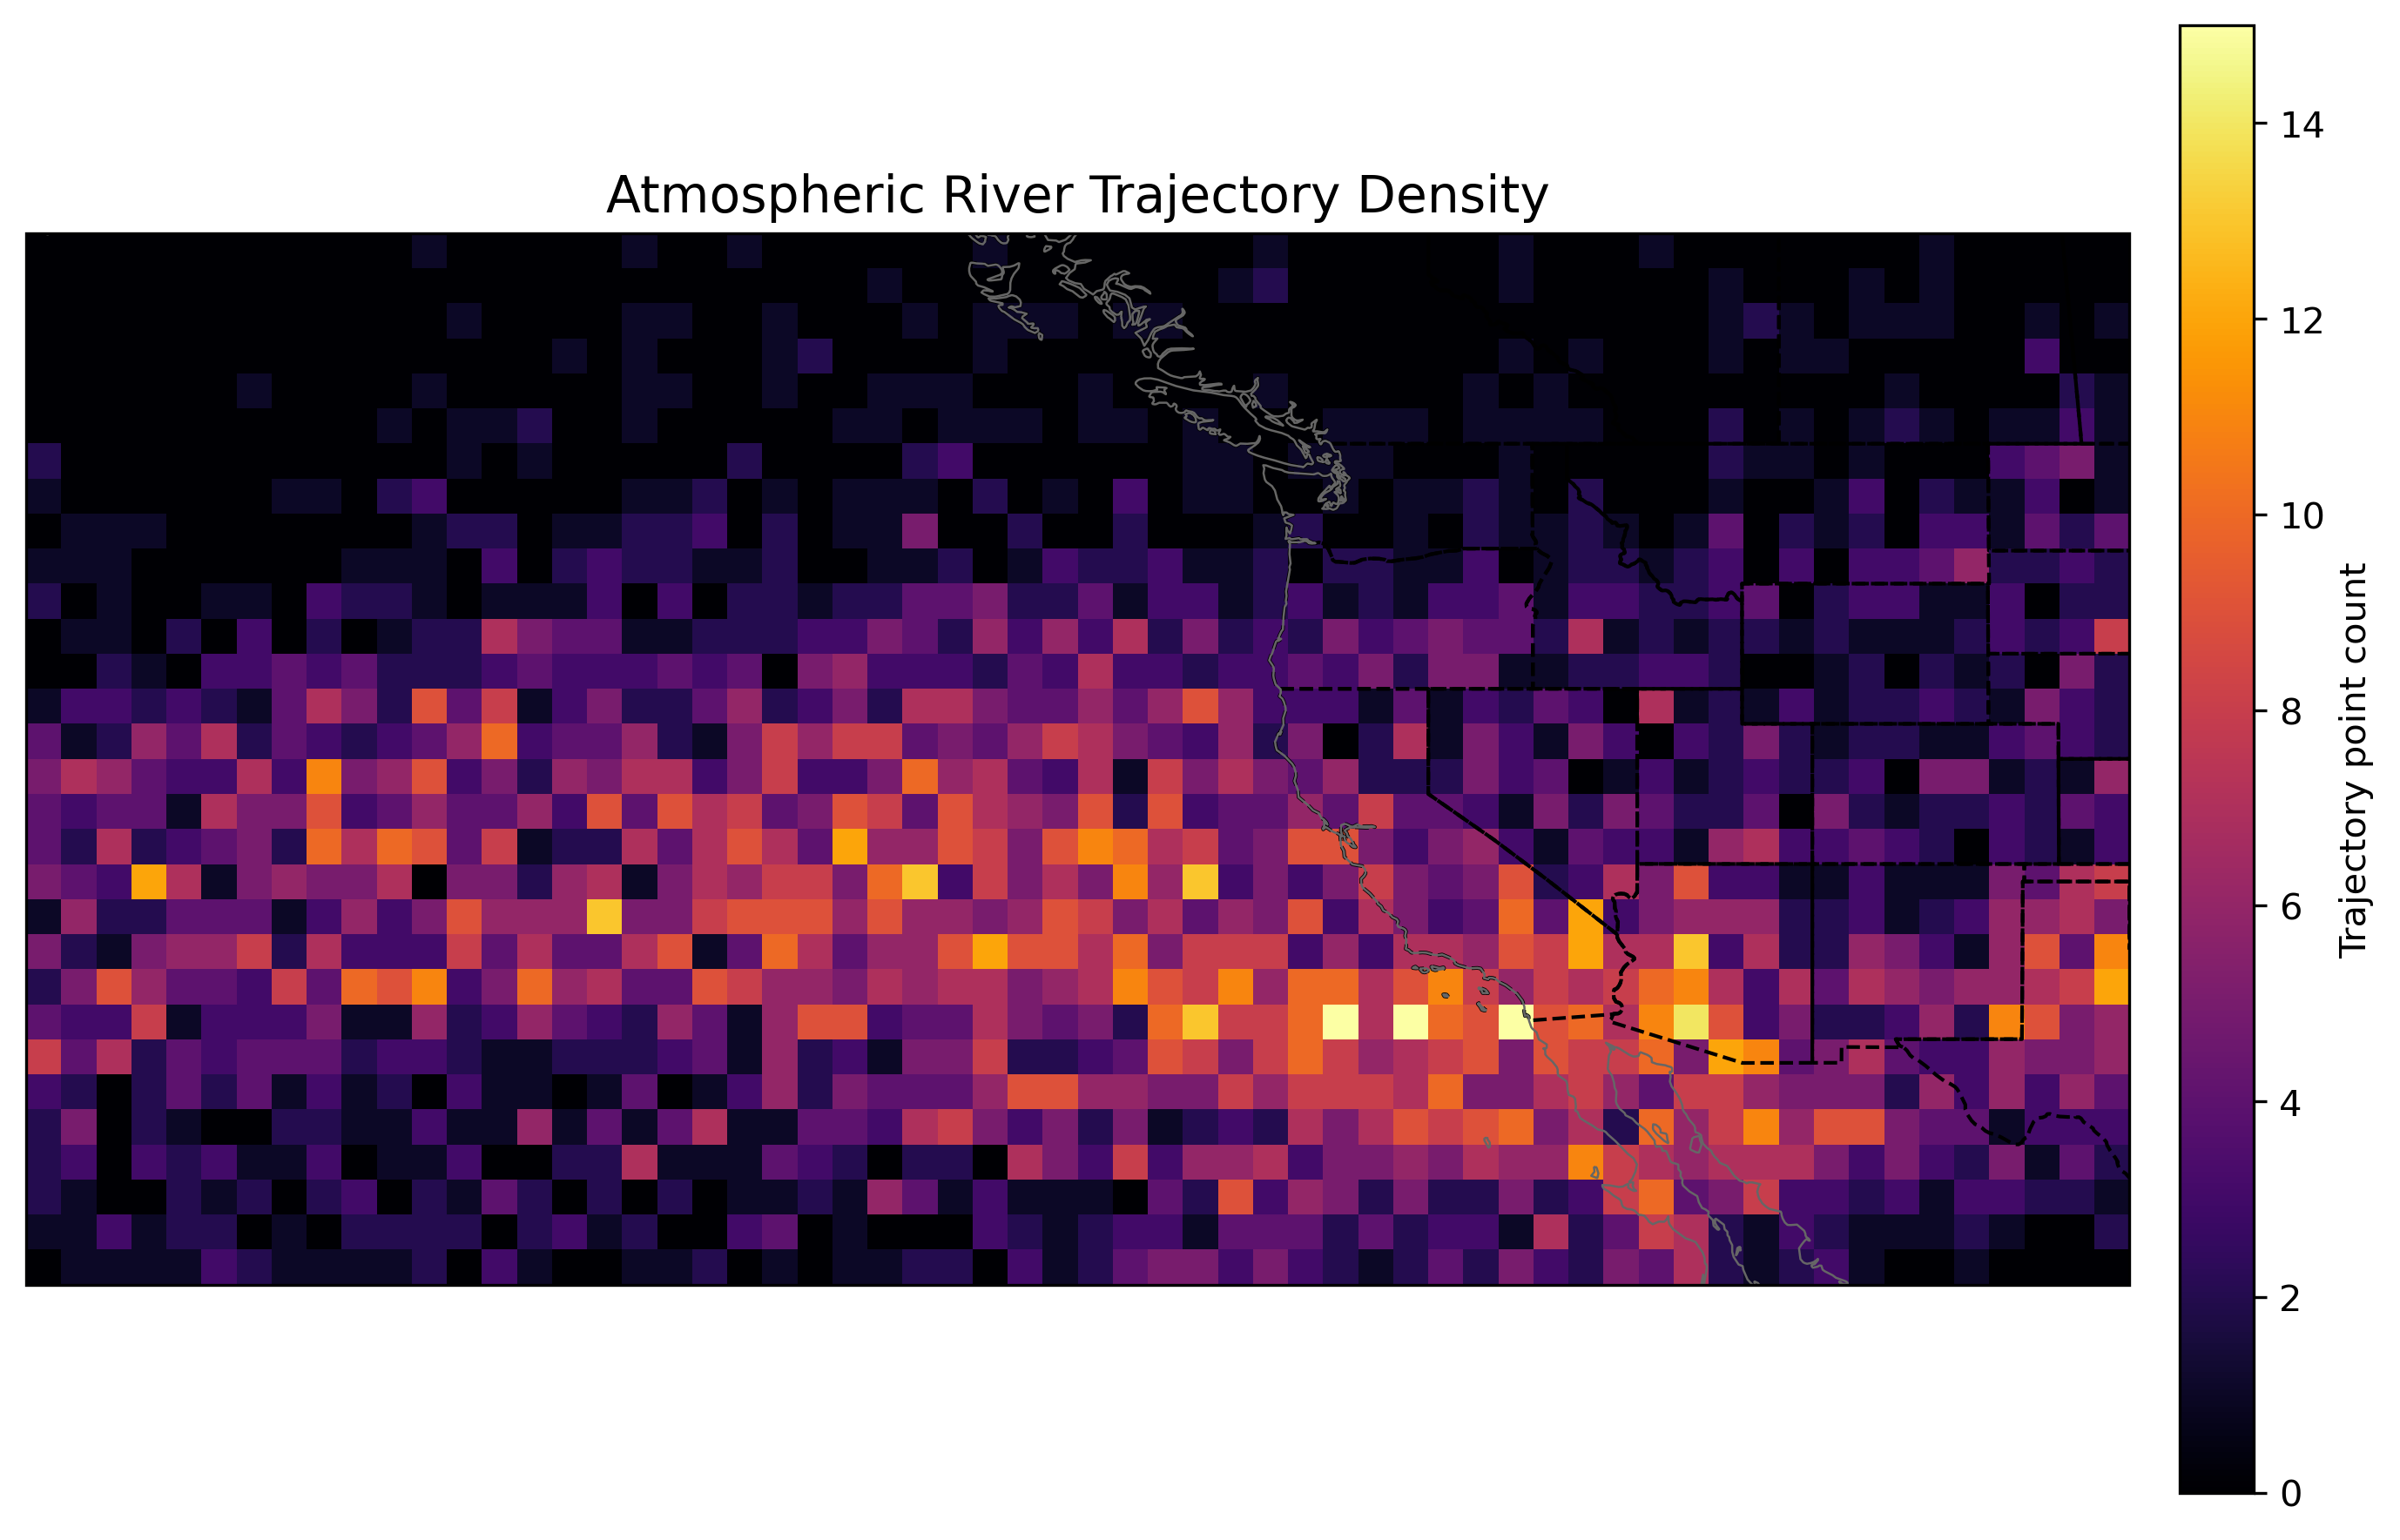

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors


datacrs = ccrs.PlateCarree()
mapcrs  = ccrs.PlateCarree(central_longitude=180)

fig = plt.figure(figsize=(10, 6), dpi=300)
ax = plt.axes(projection=mapcrs)

ax.set_extent([200, 260, 25, 55], crs=datacrs)


# Grey basemap
ax.add_feature(cfeature.OCEAN, facecolor="0.9", zorder=0)
ax.add_feature(cfeature.LAND,  facecolor="0.8", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.4", zorder=2)
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='black')

density_norm = density / traj_df["ARID"].nunique()

# Density plot
pcm = ax.pcolormesh(
    lon_edges,
    lat_edges,
    density,
    cmap="inferno",
    # norm=colors.LogNorm(vmin=1),
    # norm=density_norm,
    transform=datacrs,
    shading="auto"
)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("Trajectory point count")

ax.set_title("Atmospheric River Trajectory Density", fontsize=14)

plt.tight_layout()
plt.show()
